In [1]:
pip install pandas scipy tabulate seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("dataset/Global_Economy_Indicators.csv")

In [4]:
def clean_col_name(col_name):
    """Cleans column names to snake_case format."""
    col_name = col_name.strip().lower()
    col_name = col_name.replace(' ', '_').replace(',', '').replace('(', '').replace(')', '').replace('-', '_').replace('.', '').replace('/', '_')
    while '__' in col_name:
        col_name = col_name.replace('__', '_')
    return col_name.strip('_')

# Clean all column names
df.columns = [clean_col_name(col) for col in df.columns]

In [5]:
#Descriptive Statistics
key_stats_cols = ['gross_national_incomegni_in_usd', 'population', 'ama_exchange_rate', 
                  'exports_of_goods_and_services', 'imports_of_goods_and_services', 
                  'manufacturing_isic_d']
print("\n## 1. Descriptive Statistics for Key Indicators")
key_stats = df[key_stats_cols].describe()
print(key_stats.to_markdown(numalign="left", stralign="left"))


## 1. Descriptive Statistics for Key Indicators
|       | gross_national_incomegni_in_usd   | population   | ama_exchange_rate   | exports_of_goods_and_services   | imports_of_goods_and_services   | manufacturing_isic_d   |
|:------|:----------------------------------|:-------------|:--------------------|:--------------------------------|:--------------------------------|:-----------------------|
| count | 10512                             | 10512        | 10512               | 10491                           | 10470                           | 10469                  |
| mean  | 1.82526e+11                       | 2.85152e+07  | 357.396             | 4.67118e+10                     | 4.5915e+10                      | 3.09259e+10            |
| std   | 9.94214e+11                       | 1.1413e+08   | 2291.13             | 1.74886e+11                     | 1.80435e+11                     | 1.72391e+11            |
| min   | 3.56483e+06                       | 4359         | 4.3e-14   

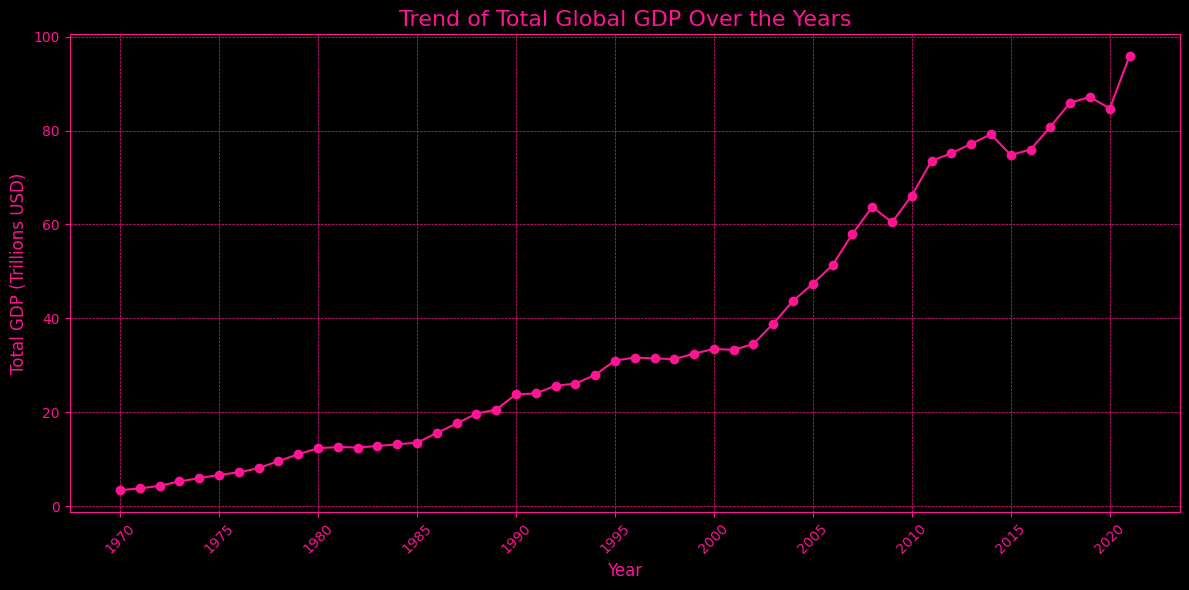

In [6]:
global_gdp = df.groupby('year')['gross_domestic_product_gdp'].sum().reset_index()
# --- Define the colors based on the image: Black background and Bright Pink/Magenta foreground ---
BACKGROUND_COLOR = '#000000' # Black
FOREGROUND_COLOR = '#FF1493' # Deep Pink (a vibrant pink/magenta)

# NOTE: The 'df' and 'global_gdp' variables must be defined before this code block, e.g.:
# global_gdp = df.groupby('year')['gross_domestic_product_gdp'].sum().reset_index()

# Start the figure, setting the figure background color to black
plt.figure(figsize=(12, 6), facecolor=BACKGROUND_COLOR)
ax = plt.gca()
ax.set_facecolor(BACKGROUND_COLOR) # Set the plot area background to black

# Plot the data with the pink color
ax.plot(global_gdp['year'], global_gdp['gross_domestic_product_gdp'] / 1e12,
        marker='o', linestyle='-',
        color=FOREGROUND_COLOR, # Line color
        markerfacecolor=FOREGROUND_COLOR, # Marker fill color
        markeredgecolor=FOREGROUND_COLOR) # Marker edge color

# Set title, labels, and ticks color to pink
ax.set_title('Trend of Total Global GDP Over the Years',
             fontsize=16, color=FOREGROUND_COLOR)
ax.set_xlabel('Year', fontsize=12, color=FOREGROUND_COLOR)
ax.set_ylabel('Total GDP (Trillions USD)', fontsize=12, color=FOREGROUND_COLOR)

# Set the grid color to pink
ax.grid(True, which='both', linestyle='--', linewidth=0.5, color=FOREGROUND_COLOR)

# Set the tick parameters (labels and tick marks color)
ax.tick_params(axis='x', colors=FOREGROUND_COLOR)
ax.tick_params(axis='y', colors=FOREGROUND_COLOR)
plt.xticks(np.arange(global_gdp['year'].min(), global_gdp['year'].max()+1, 5), rotation=45)

# Set the axis spine (border) colors to pink
for spine in ax.spines.values():
    spine.set_edgecolor(FOREGROUND_COLOR)

plt.tight_layout()
# Save the figure, ensuring the black background is included in the saved file
plt.savefig('global_gdp_trend_pink.png', facecolor=BACKGROUND_COLOR)
# plt.show()

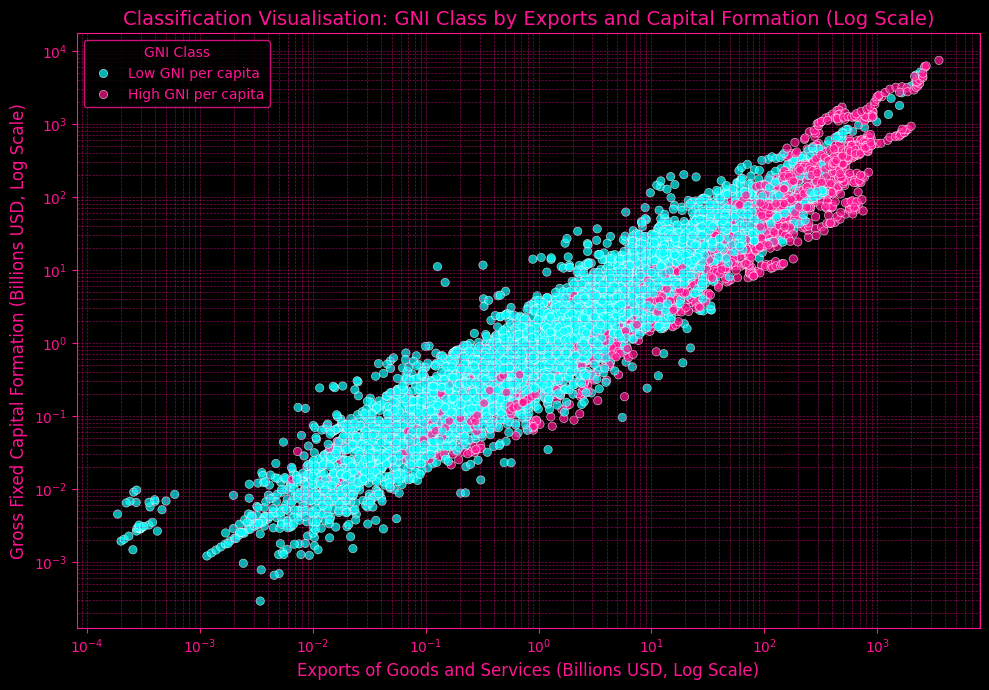

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Define the colors for the black and pink profile ---
BACKGROUND_COLOR = '#000000' # Black
FOREGROUND_COLOR = '#FF1493' # Deep Pink (vibrant pink/magenta)
LOW_GNI_COLOR = '#00FFFF'     # Vibrant Cyan/Light Blue for contrast
HIGH_GNI_COLOR = FOREGROUND_COLOR # Primary Pink for high GNI

# --- Data Loading and Preparation ---
file_name = 'dataset/Global_Economy_Indicators.csv'
df = pd.read_csv(file_name)

# 1. Clean column names and rename
df.columns = df.columns.str.strip()
column_mapping = {
    'Per capita GNI': 'per_capita_gni',
    'Exports of goods and services': 'exports_of_goods_and_services',
    'Gross fixed capital formation (including Acquisitions less disposals of valuables)': 'gross_fixed_capital_formation_including_acquisitions_less_disposals_of_valuables'
}
df.rename(columns=column_mapping, inplace=True)

# 2. Ensure necessary columns are numeric and drop NaNs
gni_cols = ['per_capita_gni', 'exports_of_goods_and_services', 
            'gross_fixed_capital_formation_including_acquisitions_less_disposals_of_valuables']

for col in gni_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce') 

df.dropna(subset=gni_cols, inplace=True)

# 3. GNI Class by Exports & Capitalization (Classification)
# Calculate GNI threshold (75th percentile)
gni_threshold = df['per_capita_gni'].quantile(0.75)
df['gni_class'] = df['per_capita_gni'].apply(lambda x: 'High GNI per capita' if x >= gni_threshold else 'Low GNI per capita')

# 4. Create Billions columns
df['exports_billions'] = df['exports_of_goods_and_services'] / 1e9
df['capital_formation_billions'] = df['gross_fixed_capital_formation_including_acquisitions_less_disposals_of_valuables'] / 1e9

# Filter out zero/negative values for log scale
df_plot = df[(df['exports_billions'] > 0) & (df['capital_formation_billions'] > 0)].copy()

# --- Plotting ---
plt.figure(figsize=(10, 7), facecolor=BACKGROUND_COLOR)
ax = plt.gca()
ax.set_facecolor(BACKGROUND_COLOR)

# Custom color palette
custom_palette = {
    'Low GNI per capita': LOW_GNI_COLOR, 
    'High GNI per capita': HIGH_GNI_COLOR
}

sns.scatterplot(
    x='exports_billions',
    y='capital_formation_billions',
    hue='gni_class',
    data=df_plot,
    alpha=0.7,
    palette=custom_palette,
    ax=ax
)

# Apply log scales
plt.xscale('log')
plt.yscale('log')

# Set title, labels, and ticks color to pink
ax.set_title('Classification Visualisation: GNI Class by Exports and Capital Formation (Log Scale)',
             fontsize=14, color=FOREGROUND_COLOR)
ax.set_xlabel('Exports of Goods and Services (Billions USD, Log Scale)',
              fontsize=12, color=FOREGROUND_COLOR)
ax.set_ylabel('Gross Fixed Capital Formation (Billions USD, Log Scale)',
              fontsize=12, color=FOREGROUND_COLOR)

# Legend text color and properties
legend = ax.legend(title='GNI Class', facecolor=BACKGROUND_COLOR, edgecolor=FOREGROUND_COLOR)
plt.setp(legend.get_texts(), color=FOREGROUND_COLOR)
plt.setp(legend.get_title(), color=FOREGROUND_COLOR)


# Set the tick parameters (labels and tick marks color)
ax.tick_params(axis='x', colors=FOREGROUND_COLOR)
ax.tick_params(axis='y', colors=FOREGROUND_COLOR)

# Set the axis spine (border) colors to pink
for spine in ax.spines.values():
    spine.set_edgecolor(FOREGROUND_COLOR)

# Set grid color to pink
ax.grid(True, which="both", ls="--", linewidth=0.5, color=FOREGROUND_COLOR, alpha=0.5)

plt.tight_layout()
plt.savefig('gni_class_classification_scatter_pink.png', facecolor=BACKGROUND_COLOR)
# plt.show()

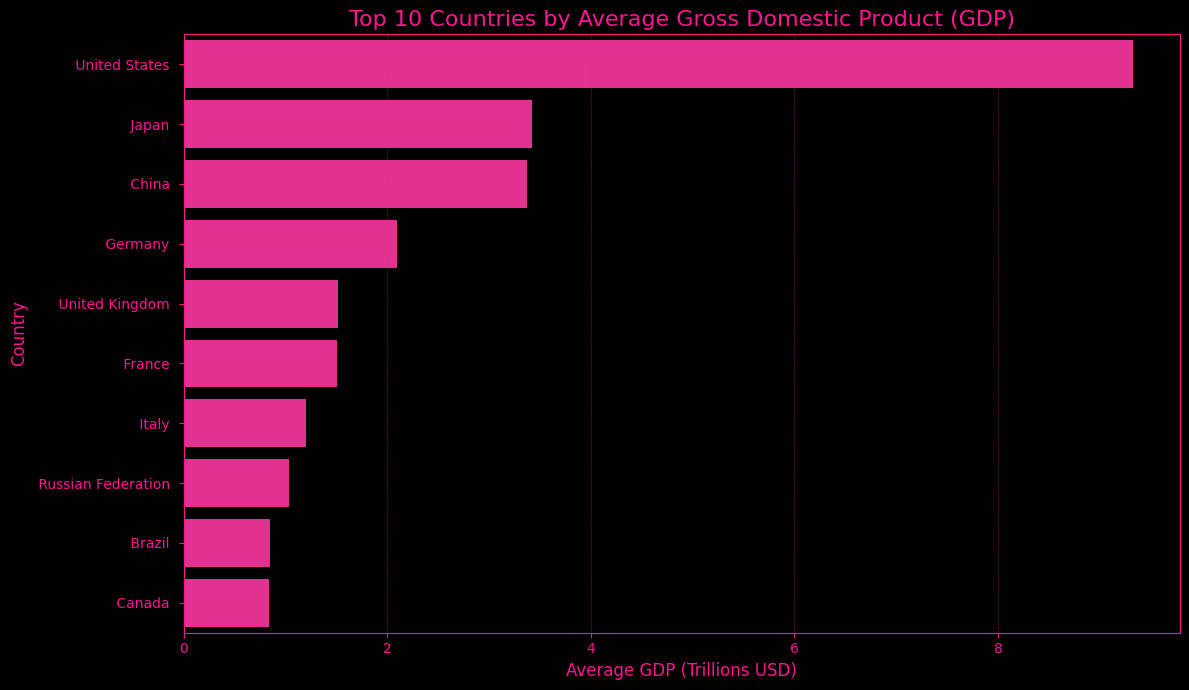

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the colors based on the image
BACKGROUND_COLOR = '#000000' # Black
FOREGROUND_COLOR = '#FF1493' # Deep Pink (a vibrant pink/magenta)

# Load the dataset
file_name = 'dataset/Global_Economy_Indicators.csv'
df = pd.read_csv(file_name)

# 1. Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# 2. Rename columns to match the user's logic
df.rename(columns={
    'Country': 'country', 
    'Gross Domestic Product (GDP)': 'gross_domestic_product_gdp'
}, inplace=True)

# 3. Ensure GDP column is numeric and handle potential missing values
df['gross_domestic_product_gdp'] = pd.to_numeric(df['gross_domestic_product_gdp'], errors='coerce')
df.dropna(subset=['gross_domestic_product_gdp', 'country'], inplace=True)

# 4. Filter out non-country aggregates based on names
non_country_names = ['World', 'Europe', 'Asia', 'Africa', 'Oceania', 'Americas', 'North America', 'South America', 'High-income economies', 'Low-income economies']
df_filtered = df[~df['country'].isin(non_country_names)].copy()

# 5. Top 10 Countries by Average GDP (from user's logic)
top_10_gdp = df_filtered.groupby('country')['gross_domestic_product_gdp'].mean().nlargest(10).reset_index()

# 6. Convert GDP to Trillions for better readability on the plot
top_10_gdp['average_gdp_trillions_usd'] = top_10_gdp['gross_domestic_product_gdp'] / 1e12

# --- Plotting with the custom color scheme ---
plt.figure(figsize=(12, 7), facecolor=BACKGROUND_COLOR)
ax = plt.gca()
ax.set_facecolor(BACKGROUND_COLOR)

# Use the specific pink color for all bars
sns.barplot(x='average_gdp_trillions_usd', y='country', data=top_10_gdp, color=FOREGROUND_COLOR, ax=ax)

# Set title, labels, and ticks color to pink
ax.set_title('Top 10 Countries by Average Gross Domestic Product (GDP)',
             fontsize=16, color=FOREGROUND_COLOR)
ax.set_xlabel('Average GDP (Trillions USD)',
              fontsize=12, color=FOREGROUND_COLOR)
ax.set_ylabel('Country',
              fontsize=12, color=FOREGROUND_COLOR)

# Set the tick parameters (labels and tick marks color)
ax.tick_params(axis='x', colors=FOREGROUND_COLOR)
ax.tick_params(axis='y', colors=FOREGROUND_COLOR)

# Set the axis spine (border) colors to pink
for spine in ax.spines.values():
    spine.set_edgecolor(FOREGROUND_COLOR)

# Add a subtle grid on the x-axis for readability of values
ax.xaxis.grid(True, which='both', linestyle='--', linewidth=0.5, color=FOREGROUND_COLOR, alpha=0.5)

plt.tight_layout()
plt.savefig('top_10_countries_avg_gdp_pink_2.png', facecolor=BACKGROUND_COLOR)
# plt.show()

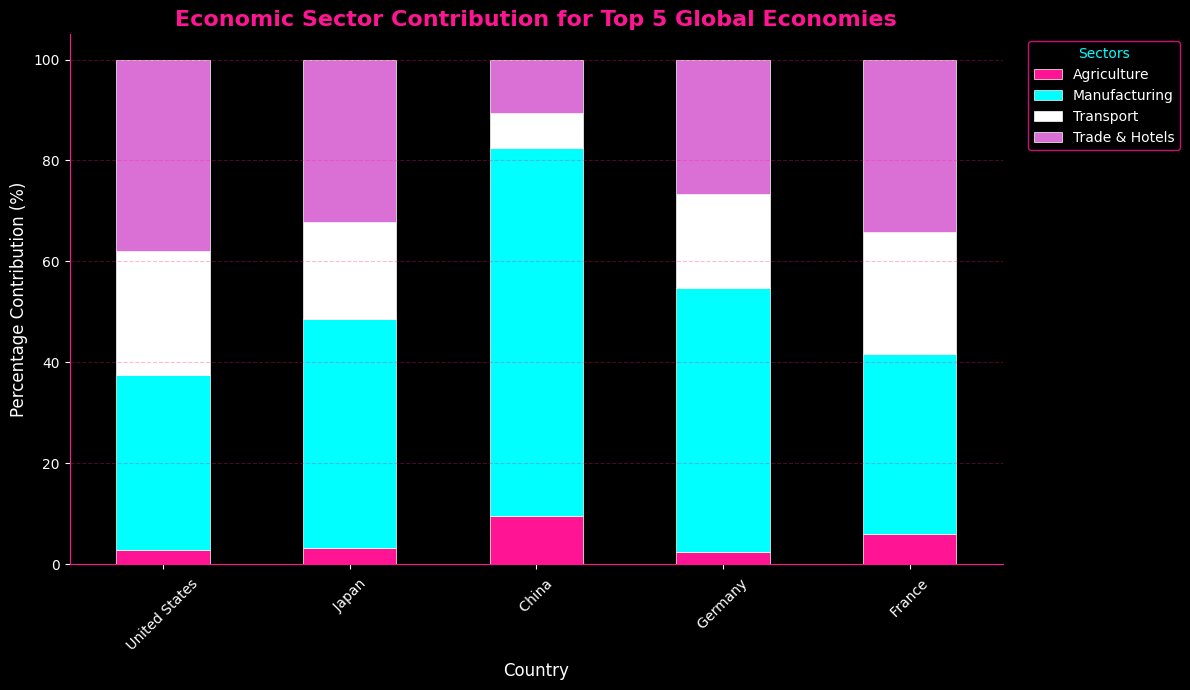

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("dataset/Global_Economy_Indicators.csv")

# Clean column names to handle potential spaces
df.columns = df.columns.str.strip()

# Define sector and target columns
gni_col = 'Gross National Income(GNI) in USD'
sector_cols = [
    'Agriculture, hunting, forestry, fishing (ISIC A-B)',
    'Manufacturing (ISIC D)',
    'Transport, storage and communication (ISIC I)',
    'Wholesale, retail trade, restaurants and hotels (ISIC G-H)'
]

# 1. Aggregate data to find the top 5 economies (by average GNI)
country_stats = df.groupby('Country').agg({
    gni_col: 'mean',
    sector_cols[0]: 'mean',
    sector_cols[1]: 'mean',
    sector_cols[2]: 'mean',
    sector_cols[3]: 'mean'
}).sort_values(by=gni_col, ascending=False).head(5)

# 2. Convert raw values into percentages
country_stats['total_sectors_sum'] = country_stats[sector_cols].sum(axis=1)
for col in sector_cols:
    country_stats[col + '_%'] = (country_stats[col] / country_stats['total_sectors_sum']) * 100

# 3. Prepare data for plotting
plot_data = country_stats[[col + '_%' for col in sector_cols]]
plot_data.columns = ['Agriculture', 'Manufacturing', 'Transport', 'Trade & Hotels']

# 4. Create the Stacked Bar Chart with the Pink Theme
fig, ax = plt.subplots(figsize=(12, 7))

# Set Background Colors
fig.set_facecolor('black')
ax.set_facecolor('black')

# Theme Palette: Deep Pink, Cyan, White, and Orchid
theme_colors = ['#FF1493', '#00FFFF', '#FFFFFF', '#DA70D6']

# Plotting
plot_data.plot(kind='bar', stacked=True, color=theme_colors, ax=ax, edgecolor='white', linewidth=0.5)

# Styling Title and Labels
ax.set_title('Economic Sector Contribution for Top 5 Global Economies', color='#FF1493', fontsize=16, fontweight='bold')
ax.set_xlabel('Country', color='white', fontsize=12)
ax.set_ylabel('Percentage Contribution (%)', color='white', fontsize=12)

# Styling Ticks and Spines
ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')
ax.spines['left'].set_color('#FF1493')
ax.spines['bottom'].set_color('#FF1493')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Add a subtle Pink Grid
ax.grid(True, linestyle='--', alpha=0.3, color='#FF1493', axis='y')

# Legend Styling
legend = ax.legend(title='Sectors', bbox_to_anchor=(1.02, 1), loc='upper left', 
                   facecolor='black', edgecolor='#FF1493', labelcolor='white')
plt.setp(legend.get_title(), color='#00FFFF')

plt.tight_layout()
plt.savefig('Economic_Sector_Contribution_Top_5_Pink_Theme.png', facecolor=fig.get_facecolor())
plt.show()

/var/folders/pp/ty3m1h8j557f1gjjmkq2pnh00000gn/T/ipykernel_16318/509807974.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


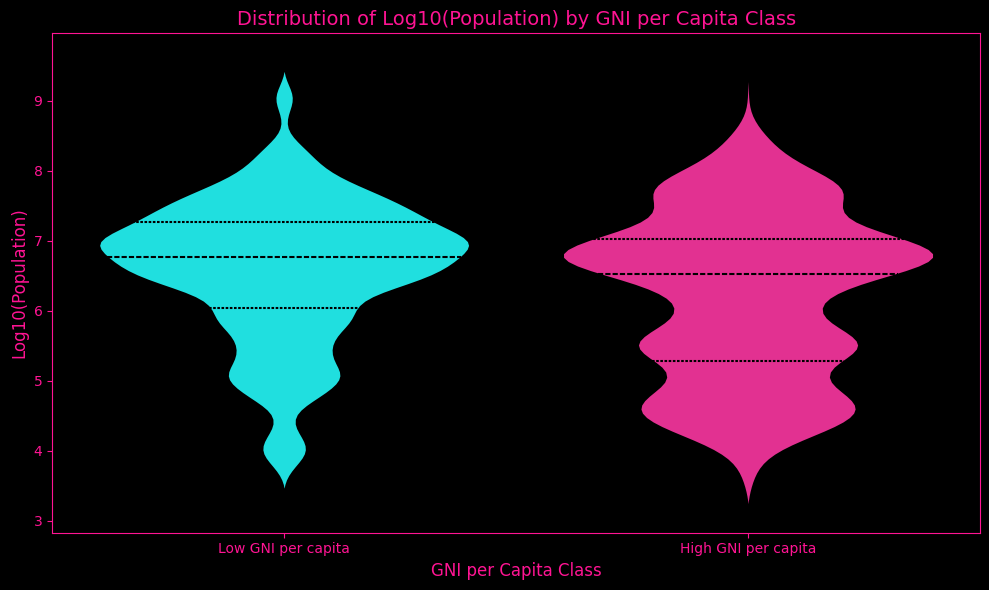

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the colors
BACKGROUND_COLOR = '#000000' # Black
FOREGROUND_COLOR = '#FF1493' # Deep Pink (vibrant pink/magenta)
LOW_GNI_COLOR = '#00FFFF'     # Vibrant Cyan/Light Blue for contrast
HIGH_GNI_COLOR = FOREGROUND_COLOR # Primary Pink for high GNI

# --- Data Loading and Preparation ---
file_name = 'dataset/Global_Economy_Indicators.csv'
df = pd.read_csv(file_name)

# 1. Clean column names
df.columns = df.columns.str.strip()

# 2. Rename columns to match the user's logic
df.rename(columns={
    'Per capita GNI': 'per_capita_gni',
    'Population': 'population'
}, inplace=True)

# 3. Ensure necessary columns are numeric and drop NaNs
gni_pop_cols = ['per_capita_gni', 'population']
for col in gni_pop_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce') 

df.dropna(subset=gni_pop_cols, inplace=True)

# 4. GNI Class by Exports & Capitalization (Classification)
gni_threshold = df['per_capita_gni'].quantile(0.75)
df['gni_class'] = df['per_capita_gni'].apply(lambda x: 'High GNI per capita' if x >= gni_threshold else 'Low GNI per capita')

# 5. Prepare data for Violin Plot: Log transform population
df_pop_violin = df.dropna(subset=['population', 'gni_class']).copy()

# Log transform population (using log10 as requested)
df_pop_violin['log_population'] = np.log10(df_pop_violin['population'].clip(lower=1))

# --- Plotting: Violin Plot ---
plt.figure(figsize=(10, 6), facecolor=BACKGROUND_COLOR)
ax = plt.gca()
ax.set_facecolor(BACKGROUND_COLOR)

# Custom color palette
custom_palette = {
    'Low GNI per capita': LOW_GNI_COLOR, 
    'High GNI per capita': HIGH_GNI_COLOR
}

sns.violinplot(
    x='gni_class',
    y='log_population',
    data=df_pop_violin,
    palette=custom_palette,
    inner='quartile', # Show quartile lines for detail
    linewidth=1.5,
    linecolor=BACKGROUND_COLOR,
    ax=ax
)

# Set title, labels, and ticks color to pink
ax.set_title('Distribution of Log10(Population) by GNI per Capita Class',
             fontsize=14, color=FOREGROUND_COLOR)
ax.set_xlabel('GNI per Capita Class',
              fontsize=12, color=FOREGROUND_COLOR)
ax.set_ylabel('Log10(Population)',
              fontsize=12, color=FOREGROUND_COLOR)

# Set the tick parameters (labels and tick marks color)
ax.tick_params(axis='x', colors=FOREGROUND_COLOR)
ax.tick_params(axis='y', colors=FOREGROUND_COLOR)

# Set the axis spine (border) colors to pink
for spine in ax.spines.values():
    spine.set_edgecolor(FOREGROUND_COLOR)

# Remove grid lines for a cleaner look that matches the other plots
ax.grid(False)

plt.tight_layout()
plt.savefig('violin_log_population_by_gni_class_pink.png', facecolor=BACKGROUND_COLOR)
# plt.show()

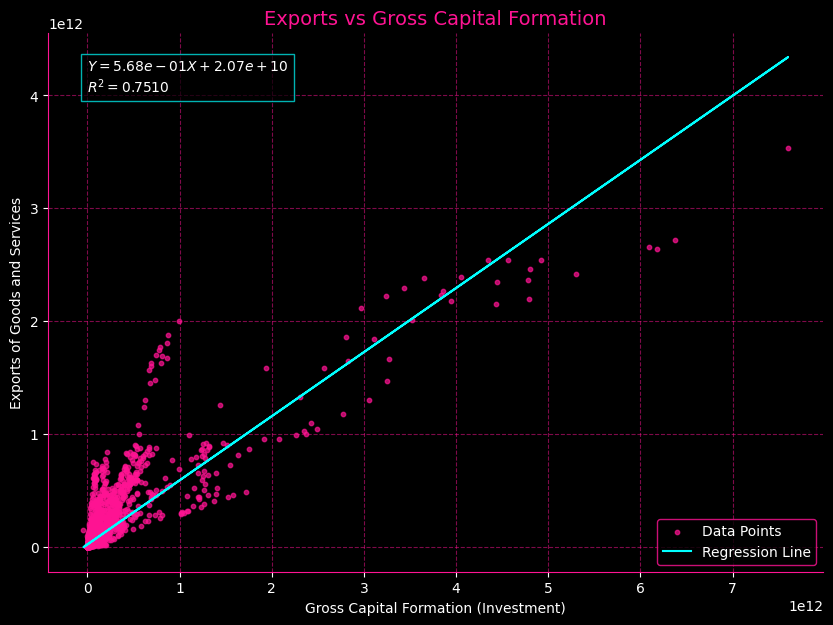

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# NOTE: This line is crucial for the code to work if 'df' is not already defined.
# It loads the data from your uploaded file.
df = pd.read_csv("dataset/Global_Economy_Indicators.csv")

# Correcting column names based on the loaded DataFrame structure (they have leading/trailing spaces)
Y_col = ' Exports of goods and services '
X_col = ' Gross capital formation '

# Filter, drop NA, and copy
df_model = df[[Y_col, X_col]].dropna().copy()

# Extract values
X = df_model[X_col].values
Y = df_model[Y_col].values

# Running Linear Regression Model
slope, intercept, r_value, p_value, std_err = linregress(X, Y)

# Calculating R-squared
R_squared = r_value**2

# Visualization
regression_line = slope * X + intercept

# ----------------------------------------------------------------
# Plotting with specified pink/cyan/black theme
fig, ax = plt.subplots(figsize=(10, 7))

# Set the figure and axes background to black
fig.set_facecolor('black')
ax.set_facecolor('black')

# Scatter Plot - Pink Points (#FF1493 is DeepPink)
ax.scatter(X, Y, label='Data Points', color='#FF1493', alpha=0.7, s=10)

# Regression Line - Cyan
ax.plot(X, regression_line, color='cyan', label='Regression Line')

# Set Title, Labels, and Ticks to be visible on black
ax.set_title('Exports vs Gross Capital Formation', color='#FF1493', fontsize=14)
ax.set_xlabel('Gross Capital Formation (Investment)', color='white')
ax.set_ylabel('Exports of Goods and Services', color='white')

# Set tick and spine colors to match the theme (white ticks, pink spines)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['left'].set_color('#FF1493')
ax.spines['bottom'].set_color('#FF1493')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Add a pink grid
ax.grid(True, linestyle='--', alpha=0.5, color='#FF1493')

# Regression Formula and R-squared Annotation (top left, as requested)
formula_text = f'$Y = {slope:.2e}X + {intercept:.2e}$\n$R^2 = {R_squared:.4f}$'
ax.text(
    0.05, 0.95,
    formula_text,
    transform=ax.transAxes,
    color='white',
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='cyan') # Black background for text, cyan border
)

# Legend - Adjusted to the lower right to avoid overlap
ax.legend(loc='lower right', facecolor='black', edgecolor='#FF1493', labelcolor='white')

# Save the plot
plt.savefig('exports_vs_gci_regression_styled.png', facecolor=fig.get_facecolor())
plt.show()

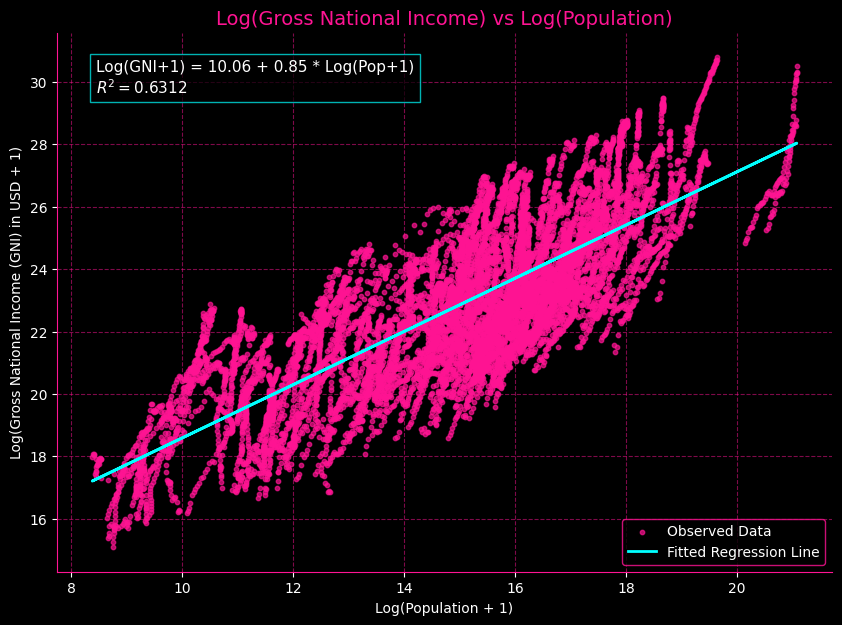

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# NOTE: This line is crucial for the code to work if 'df' is not already defined.
# It loads the data from your uploaded file.
df = pd.read_csv("dataset/Global_Economy_Indicators.csv")

# ----------------------------------------------------------------
# Assigning Columns: Corrected column names for spaces
Y_col = ' Gross National Income(GNI) in USD '
X_col = ' Population '
df_model = df[[Y_col, X_col]].dropna().copy()
# ----------------------------------------------------
# Log Transform data for Numerical Stability (Log-Log Model)
df_model['log_Y'] = np.log(df_model[Y_col] + 1)
df_model['log_X'] = np.log(df_model[X_col] + 1)
# ----------------------------------------------------
# Replacing Null Values & Assigning Variables:
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()
X = df_model['log_X']
Y = df_model['log_Y']
# ----------------------------------------------------
# Regression Calculation using NumPy
slope, intercept = np.polyfit(X, Y, 1)
Y_pred = slope * X + intercept
# Calculating R-Squared
ss_res = np.sum((Y - Y_pred)**2)
ss_tot = np.sum((Y - Y.mean())**2)
r_squared = 1 - (ss_res / ss_tot)
# ----------------------------------------------------
# Visualisation: Applying the Black/Pink/Cyan Theme

fig, ax = plt.subplots(figsize=(10, 7))

# Set the figure and axes background to black
fig.set_facecolor('black')
ax.set_facecolor('black')

# Scatter Plot - Pink Points (#FF1493 is DeepPink)
ax.scatter(X, Y, label='Observed Data', color='#FF1493', alpha=0.7, s=10)

# Regression Line - Cyan
ax.plot(X, Y_pred, color='cyan', linewidth=2, label='Fitted Regression Line')

# Set Title, Labels, and Ticks to be visible on black
ax.set_title('Log(Gross National Income) vs Log(Population)', color='#FF1493', fontsize=14)
ax.set_xlabel('Log(Population + 1)', color='white')
ax.set_ylabel('Log(Gross National Income (GNI) in USD + 1)', color='white')

# Set tick and spine colors to match the theme (white ticks, pink spines)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['left'].set_color('#FF1493')
ax.spines['bottom'].set_color('#FF1493')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Add a pink grid
ax.grid(True, linestyle='--', alpha=0.5, color='#FF1493')

# Regression Formula and R-squared Annotation (Using plain text to ensure no Mathtext errors)
equation_text = (
    f'Log(GNI+1) = {intercept:.2f} + {slope:.2f} * Log(Pop+1)'
    f'\n$R^2 = {r_squared:.4f}$' # R^2 is simple enough to keep in LaTeX
)

ax.text(
    0.05, 0.95,
    equation_text,
    transform=ax.transAxes,
    color='white',
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='cyan') # Black background for text, cyan border
)

# Legend - Adjusted to the lower right to avoid overlap
ax.legend(loc='lower right', facecolor='black', edgecolor='#FF1493', labelcolor='white')

# Save the plot
plt.savefig('Linear_Regression_GNI_vs_Population_Styled_Final.png', facecolor=fig.get_facecolor())
plt.show()

--- Multiple Regression Results (Imports vs Total Domestic Consumption) ---
Model: Imports = B0 + B1*Household Consumption + B2*Government Consumption
Test Set R-squared (Viability): 0.825185
Test Set RMSE: 70428592060.75
Intercept (B0): 2.76e-12
Coefficient for Household Consumption (B1): -0.0604
Coefficient for Government Consumption (B2): 1.3100


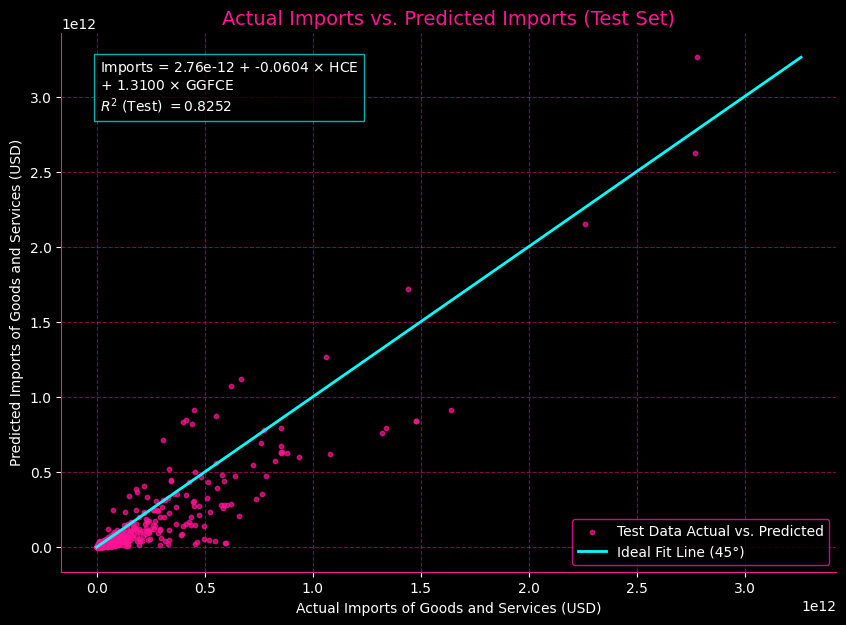

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file to ensure the DataFrame 'df' is defined.
df = pd.read_csv("dataset/Global_Economy_Indicators.csv")

# ----------------------------------------------------
# Defining Variables: Corrected column names for spaces
Y_col = ' Imports of goods and services '
X_cols = [
    ' Household consumption expenditure (including Non-profit institutions serving households) ',
    ' General government final consumption expenditure '
]
df_model = df[[Y_col] + X_cols].dropna().copy()
# ----------------------------------------------------------------
# Multiple Regression Calculation - Data Split
np.random.seed(42) # For reproducible split
shuffled_indices = np.random.permutation(len(df_model))
test_set_size = int(len(df_model) * 0.2)
test_indices = shuffled_indices[:test_set_size]
train_indices = shuffled_indices[test_set_size:]
train_data = df_model.iloc[train_indices]
test_data = df_model.iloc[test_indices]
# ----------------------------------------------------------------
# Prepare X data with intercept column for OLS
X_train_data = train_data[X_cols].values
X_test_data = test_data[X_cols].values
Y_train = train_data[Y_col].values
Y_test = test_data[Y_col].values
# Add intercept (column of ones)
X_train = np.hstack([np.ones((X_train_data.shape[0], 1)), X_train_data])
X_test = np.hstack([np.ones((X_test_data.shape[0], 1)), X_test_data])
# ----------------------------------------------------------------
# Regression Calculation:
# betas = [B0, B1 (Household Consumption), B2 (Government Consumption)]
betas = np.linalg.lstsq(X_train, Y_train, rcond=None)[0]
# Prediction:
Y_pred_test = X_test @ betas
# Data Metrics Viability Calculation:
mse_test = np.mean((Y_test - Y_pred_test)**2)
rmse_test = np.sqrt(mse_test) # Root Mean Squared Error (RMSE)
# RSquared for Test Viability Metric:
ss_res_test = np.sum((Y_test - Y_pred_test)**2)
ss_tot_test = np.sum((Y_test - Y_test.mean())**2)
r_squared_test = 1 - (ss_res_test / ss_tot_test)
# ----------------------------------------------------------------
# Printing Results: (Optional for display, but included for completeness)
print("--- Multiple Regression Results (Imports vs Total Domestic Consumption) ---")
print(f"Model: Imports = B0 + B1*Household Consumption + B2*Government Consumption")
print(f"Test Set R-squared (Viability): {r_squared_test:.6f}")
print(f"Test Set RMSE: {rmse_test:.2f}")
print(f"Intercept (B0): {betas[0]:.2e}")
print(f"Coefficient for Household Consumption (B1): {betas[1]:.4f}")
print(f"Coefficient for Government Consumption (B2): {betas[2]:.4f}")
# ----------------------------------------------------------------
# Visualisation: Applying the Black/Pink/Cyan Theme
fig, ax = plt.subplots(figsize=(10, 7))

# Set the figure and axes background to black
fig.set_facecolor('black')
ax.set_facecolor('black')

# Scatter Plot - Pink Points (#FF1493 is DeepPink)
ax.scatter(Y_test, Y_pred_test, alpha=0.7, s=10, label='Test Data Actual vs. Predicted', color='#FF1493')

# Ideal Fit Line (45°) - Cyan
min_val = min(Y_test.min(), Y_pred_test.min())
max_val = max(Y_test.max(), Y_pred_test.max())
ax.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='-', linewidth=2, label='Ideal Fit Line (45°)')

# Set Title, Labels, and Ticks to be visible on black
ax.set_title('Actual Imports vs. Predicted Imports (Test Set)', color='#FF1493', fontsize=14)
ax.set_xlabel('Actual Imports of Goods and Services (USD)', color='white')
ax.set_ylabel('Predicted Imports of Goods and Services (USD)', color='white')

# Set tick and spine colors to match the theme (white ticks, pink spines)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['left'].set_color('#FF1493')
ax.spines['bottom'].set_color('#FF1493')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Add a pink grid
ax.grid(True, linestyle='--', alpha=0.5, color='#FF1493')

# Format tick labels to scientific notation
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# Regression Formula and R-squared Annotation (top left)
# Using LaTeX syntax for the R^2 and multiplication symbol (\times)
formula_text = (
    f'Imports = {betas[0]:.2e} + {betas[1]:.4f} $\\times$ HCE'
    f'\n+ {betas[2]:.4f} $\\times$ GGFCE'
    f'\n$R^2$ (Test) $= {r_squared_test:.4f}$'
)

ax.text(
    0.05, 0.95,
    formula_text,
    transform=ax.transAxes,
    color='white',
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='cyan') # Black background for text, cyan border
)

# Legend - Adjusted to the lower right to avoid overlap
ax.legend(loc='lower right', facecolor='black', edgecolor='#FF1493', labelcolor='white')

# Save the plot
plt.savefig('Multiple_Regression_Imports_vs_Consumption_Styled.png', facecolor=fig.get_facecolor())
plt.show()

/Users/farhaz/Documents/SAIT/Data Analytics/✱410/FInal Project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/farhaz/Documents/SAIT/Data Analytics/✱410/FInal Project/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


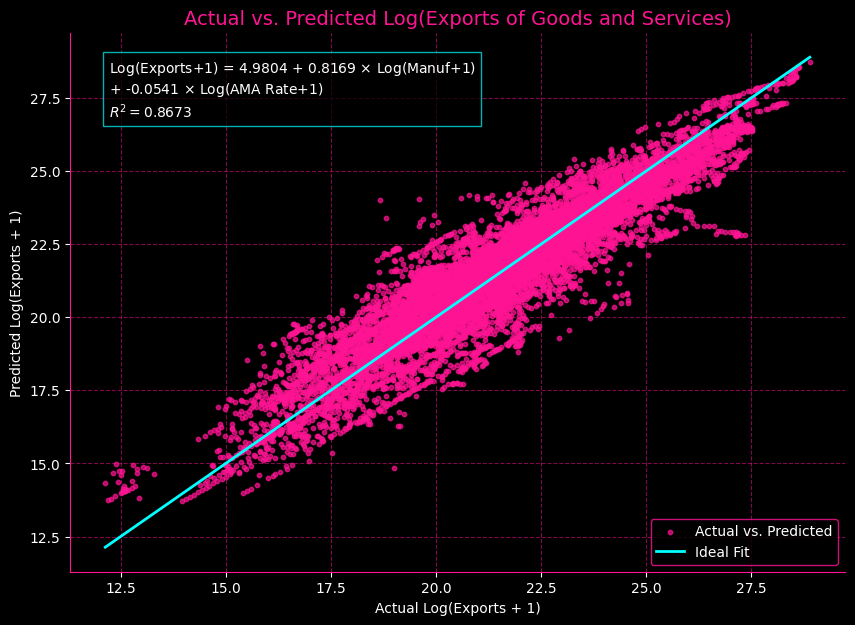

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file to ensure 'df' is defined.
df = pd.read_csv("dataset/Global_Economy_Indicators.csv")

# ----------------------------------------------------
# Defining Variables: Corrected column names for spaces
Y_col = ' Exports of goods and services '
X_cols = [' Manufacturing (ISIC D) ', ' AMA exchange rate ']
df_model = df[[Y_col] + X_cols].dropna().copy()
# ----------------------------------------------------
# Log Transformation for numerical stability:
df_model['log_Y'] = np.log(df_model[Y_col] + 1)
df_model['log_X1'] = np.log(df_model[X_cols[0]] + 1)
df_model['log_X2'] = np.log(df_model[X_cols[1]] + 1)
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()
Y = df_model['log_Y'].values
X_data = df_model[['log_X1', 'log_X2']].values
# Add intercept to X - Column:
X = np.hstack([np.ones((X_data.shape[0], 1)), X_data])
# Regression Calculation using NumPy Linear Algebra OLS Solution:
betas = np.linalg.lstsq(X, Y, rcond=None)[0]
# Calculate predicted Y values
Y_pred = X @ betas
# Calculate R-squared: R^2 = 1 - (SS_res / SS_tot)
ss_res = np.sum((Y - Y_pred)**2)
ss_tot = np.sum((Y - Y.mean())**2)
r_squared = 1 - (ss_res / ss_tot)
# ----------------------------------------------------
# Visualisation: Applying the Black/Pink/Cyan Theme
fig, ax = plt.subplots(figsize=(10, 7))

# Set the figure and axes background to black
fig.set_facecolor('black')
ax.set_facecolor('black')

# Scatter Plot - Pink Points (#FF1493 is DeepPink)
ax.scatter(Y, Y_pred, alpha=0.7, s=10, color='#FF1493', label='Actual vs. Predicted')

# Plot the ideal 45-degree line (Y_actual = Y_predicted) - Cyan
min_val = min(Y.min(), Y_pred.min())
max_val = max(Y.max(), Y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color='cyan', linestyle='-', linewidth=2, label='Ideal Fit')

# Set Title, Labels, and Ticks to be visible on black
ax.set_title('Actual vs. Predicted Log(Exports of Goods and Services)', color='#FF1493', fontsize=14)
ax.set_xlabel('Actual Log(Exports + 1)', color='white')
ax.set_ylabel('Predicted Log(Exports + 1)', color='white')

# Set tick and spine colors to match the theme (white ticks, pink spines)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.spines['left'].set_color('#FF1493')
ax.spines['bottom'].set_color('#FF1493')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Add a pink grid
ax.grid(True, linestyle='--', alpha=0.5, color='#FF1493')

# Regression Formula and R-squared Annotation (top left, using plain text for formula part)
formula_text = (
    f'Log(Exports+1) = {betas[0]:.4f} + {betas[1]:.4f} $\\times$ Log(Manuf+1)'
    f'\n+ {betas[2]:.4f} $\\times$ Log(AMA Rate+1)'
    f'\n$R^2 = {r_squared:.4f}$'
)

ax.text(
    0.05, 0.95,
    formula_text,
    transform=ax.transAxes,
    color='white',
    fontsize=10,
    verticalalignment='top',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='cyan') # Black background for text, cyan border
)

# Legend - Adjusted to the lower right to avoid overlap
ax.legend(loc='lower right', facecolor='black', edgecolor='#FF1493', labelcolor='white')

# Save the plot
plt.savefig('Multiple_Regression_Exports_Actual_vs_Predicted_Styled.png', facecolor=fig.get_facecolor())
plt.show()